In [9]:
import pandas as pd
import numpy as np
import os
import kagglehub
from PIL import Image


In [62]:
from NeuralNetwork import (
    Dense,
    ReLU,
    LeakyReLU,
    Sigmoid,
    NeuralNetwork,
    MSELoss,
    CrossEntropyLoss
)

from Optimizers import (Adam, SGD, RMSProp, Nesterov, Momentum)

In [11]:
network = NeuralNetwork()

network.add(Dense(3, 5))
network.add(ReLU())
network.add(Dense(5, 2))

In [12]:
loss_function = MSELoss()

In [13]:
optimizer = Adam(learning_rate=0.001)

In [15]:
x = np.array([[1.0, 2.0, 3.0]])
target = np.array([[0.5, 1.0]])

for epoch in range(1000):

    # 1. Forward
    prediction = network.forward(x)

    # 2. Loss
    loss = loss_function.forward(prediction, target)

    # 3. Backward from loss
    gradient = loss_function.backward(prediction, target)

    # 4. Backward through network
    network.backward(gradient)

    # 5. Update weights
    optimizer.step(network.layers)

    if epoch % 100 == 0:
        print(
            "Epoch:", epoch,
            "Loss:", loss,
            "Prediction:", prediction
        )

Epoch: 0 Loss: 0.6249806443955408 Prediction: [[7.09818985e-06 1.58066597e-05]]
Epoch: 100 Loss: 0.3373821843361038 Prediction: [[0.21677775 0.22892962]]
Epoch: 200 Loss: 0.05874490456692998 Prediction: [[0.51598929 0.65760527]]
Epoch: 300 Loss: 0.002412141122417862 Prediction: [[0.51493282 0.93216717]]
Epoch: 400 Loss: 1.299741385802195e-05 Prediction: [[0.50100209 0.99500094]]
Epoch: 500 Loss: 1.0774167621971024e-08 Prediction: [[0.50002888 0.99985608]]
Epoch: 600 Loss: 6.522312881614379e-13 Prediction: [[0.50000022 0.99999888]]
Epoch: 700 Loss: 1.0217434589195078e-17 Prediction: [[0.5 1. ]]
Epoch: 800 Loss: 1.413390675291794e-22 Prediction: [[0.5 1. ]]
Epoch: 900 Loss: 5.7401771917198026e-27 Prediction: [[0.5 1. ]]


## Working on more data

In [16]:
# =========================
# GENERATE DATA
# =========================

np.random.seed(42)

num_samples = 1000

X = np.random.uniform(
    -5,
    5,
    size=(num_samples, 3)
)

Y = np.zeros((num_samples, 2))


for i in range(num_samples):

    x1 = X[i][0]
    x2 = X[i][1]
    x3 = X[i][2]

    Y[i][0] = 2*x1 + 3*x2 - x3
    Y[i][1] = x1 - 2*x2 + 4*x3

In [17]:
X.shape

(1000, 3)

In [18]:
Y.shape

(1000, 2)

In [19]:
network = NeuralNetwork()

network.add(Dense(3, 16))
network.add(ReLU())

network.add(Dense(16, 16))
network.add(ReLU())

network.add(Dense(16, 2))

In [20]:
loss_function = MSELoss()

optimizer = Adam(
    learning_rate=0.001
)

In [22]:
epochs = 100

for epoch in range(epochs):

    total_loss = 0

    for i in range(num_samples):

        # Keep batch dimension
        x = X[i:i+1]
        target = Y[i:i+1]

        # =========================
        # FORWARD
        # =========================

        prediction = network.forward(x)

        # =========================
        # LOSS
        # =========================

        loss = loss_function.forward(
            prediction,
            target
        )

        total_loss += loss

        # =========================
        # BACKWARD
        # =========================

        gradient = loss_function.backward(
            prediction,
            target
        )

        network.backward(gradient)

        # =========================
        # UPDATE
        # =========================

        optimizer.step(network.layers)

    average_loss = total_loss / num_samples

    if epoch % 10 == 0:
        print(
            "Epoch:",
            epoch,
            "Loss:",
            average_loss
        )

Epoch: 0 Loss: 75.18696831519271
Epoch: 10 Loss: 0.027002731480888192
Epoch: 20 Loss: 0.01949856141330138
Epoch: 30 Loss: 0.01624536348067571
Epoch: 40 Loss: 0.01587018535906063
Epoch: 50 Loss: 0.012810723447103788
Epoch: 60 Loss: 0.011729999133508171
Epoch: 70 Loss: 0.0123285725149823
Epoch: 80 Loss: 0.01167419290485575
Epoch: 90 Loss: 0.010907686704126719


In [23]:
test = np.array([
    2.0,
    -1.0,
    3.0
])

In [24]:
actual = np.array([
    2*test[0] + 3*test[1] - test[2],
    test[0] - 2*test[1] + 4*test[2]
])

prediction = network.forward(test)

print("Input:")
print(test)

print("Expected:")
print(actual)

print("Network:")
print(prediction)

Input:
[ 2. -1.  3.]
Expected:
[-2. 16.]
Network:
[-2.15677821 15.96910035]


## Img Dataset

In [25]:
project_folder = r"C:\Users\User\Desktop\Practice\Extra\Neural Network"

dataset_folder = os.path.join(
    project_folder,
    "dataset"
)

os.makedirs(
    dataset_folder,
    exist_ok=True
)

os.environ["KAGGLEHUB_CACHE"] = dataset_folder

path = kagglehub.dataset_download(
    "singhnavjot2062001/geometric-shapes-circle-square-triangle"
)

print(path)

C:\Users\User\Desktop\Practice\Extra\Neural Network\dataset\datasets\singhnavjot2062001\geometric-shapes-circle-square-triangle\versions\58


In [26]:
for root, folders, files in os.walk(path):
    print(root)
    print("Folders:", folders)
    print("Images:", files[:3])
    print()

C:\Users\User\Desktop\Practice\Extra\Neural Network\dataset\datasets\singhnavjot2062001\geometric-shapes-circle-square-triangle\versions\58
Folders: ['Circle', 'Square', 'Triangle']
Images: []

C:\Users\User\Desktop\Practice\Extra\Neural Network\dataset\datasets\singhnavjot2062001\geometric-shapes-circle-square-triangle\versions\58\Circle
Folders: []
Images: ['circle_136.png', 'circle_137.png', 'circle_138.png']

C:\Users\User\Desktop\Practice\Extra\Neural Network\dataset\datasets\singhnavjot2062001\geometric-shapes-circle-square-triangle\versions\58\Square
Folders: []
Images: ['square_136.png', 'square_137.png', 'square_138.png']

C:\Users\User\Desktop\Practice\Extra\Neural Network\dataset\datasets\singhnavjot2062001\geometric-shapes-circle-square-triangle\versions\58\Triangle
Folders: []
Images: ['triangle_136.png', 'triangle_137.png', 'triangle_138.png']



In [81]:
class_names = ["circle", "square", "triangle"]

X = []
y = []

for label, class_name in enumerate(class_names):

    class_folder = os.path.join(path, class_name)

    for file_name in os.listdir(class_folder):

        file_path = os.path.join(class_folder, file_name)

        try:
            image = Image.open(file_path)

            # grayscale
            image = image.convert("L")

            # resize
            image = image.resize((32, 32))

            # image -> numpy
            image = np.array(image, dtype=np.float32)

            # normalize 0-255 -> 0-1
            image = image / 255.0

            # 32x32 -> 1024
            image = image.flatten()

            X.append(image)
            y.append(label)

        except:
            pass

In [82]:
X = np.array(X)
y = np.array(y)

In [83]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (195, 1024)
y shape: (195,)


In [84]:
indices = np.random.permutation(len(X))

X = X[indices]
y = y[indices]

In [85]:
split = int(len(X) * 0.8)

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (156, 1024)
Testing: (39, 1024)


In [86]:
network = NeuralNetwork()

network.add(Dense(1024, 128))
network.add(ReLU())

network.add(Dense(128, 64))
network.add(ReLU())

network.add(Dense(64, 3))

In [87]:
loss_function = CrossEntropyLoss()

optimizer = Adam(
    learning_rate=0.001
)

In [88]:
epochs = 100
batch_size = 32

for epoch in range(epochs):

    # shuffle training data every epoch
    indices = np.random.permutation(len(X_train))

    X_train = X_train[indices]
    y_train = y_train[indices]

    total_loss = 0
    correct = 0


    for start in range(0, len(X_train), batch_size):

        end = start + batch_size

        x_batch = X_train[start:end]
        y_batch = y_train[start:end]


        # =========================
        # FORWARD
        # =========================

        logits = network.forward(x_batch)


        # =========================
        # LOSS
        # =========================

        loss = loss_function.forward(
            logits,
            y_batch
        )

        total_loss += loss


        # =========================
        # ACCURACY
        # =========================

        predictions = np.argmax(
            logits,
            axis=1
        )

        correct += np.sum(
            predictions == y_batch
        )


        # =========================
        # BACKWARD
        # =========================

        gradient = loss_function.backward()

        network.backward(gradient)


        # =========================
        # UPDATE
        # =========================

        optimizer.step(network.layers)


    average_loss = (
        total_loss
        / np.ceil(len(X_train) / batch_size)
    )

    accuracy = correct / len(X_train)


    print(
        f"Epoch {epoch + 1}/{epochs}",
        f"Loss: {average_loss:.4f}",
        f"Accuracy: {accuracy:.4f}"
    )

Epoch 1/100 Loss: 1.1011 Accuracy: 0.3269
Epoch 2/100 Loss: 1.0963 Accuracy: 0.3397
Epoch 3/100 Loss: 1.0937 Accuracy: 0.3654
Epoch 4/100 Loss: 1.0867 Accuracy: 0.4551
Epoch 5/100 Loss: 1.0721 Accuracy: 0.5192
Epoch 6/100 Loss: 1.0419 Accuracy: 0.5321
Epoch 7/100 Loss: 1.0075 Accuracy: 0.5192
Epoch 8/100 Loss: 0.9503 Accuracy: 0.5192
Epoch 9/100 Loss: 0.9094 Accuracy: 0.5577
Epoch 10/100 Loss: 0.8616 Accuracy: 0.5449
Epoch 11/100 Loss: 0.8526 Accuracy: 0.5513
Epoch 12/100 Loss: 0.8255 Accuracy: 0.5769
Epoch 13/100 Loss: 0.8020 Accuracy: 0.5577
Epoch 14/100 Loss: 0.7787 Accuracy: 0.6090
Epoch 15/100 Loss: 0.7537 Accuracy: 0.5962
Epoch 16/100 Loss: 0.7397 Accuracy: 0.6026
Epoch 17/100 Loss: 0.7086 Accuracy: 0.6346
Epoch 18/100 Loss: 0.6865 Accuracy: 0.6474
Epoch 19/100 Loss: 0.6935 Accuracy: 0.6346
Epoch 20/100 Loss: 0.6679 Accuracy: 0.6731
Epoch 21/100 Loss: 0.6861 Accuracy: 0.6538
Epoch 22/100 Loss: 0.6506 Accuracy: 0.6474
Epoch 23/100 Loss: 0.6551 Accuracy: 0.6795
Epoch 24/100 Loss: 0

In [89]:
test_logits = network.forward(X_test)

test_predictions = np.argmax(
    test_logits,
    axis=1
)

test_accuracy = np.mean(
    test_predictions == y_test
)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9487179487179487


In [90]:
for i in range(10):

    prediction = test_predictions[i]
    actual = y_test[i]

    print(
        "Predicted:",
        class_names[prediction],
        "| Actual:",
        class_names[actual]
    )

Predicted: circle | Actual: circle
Predicted: circle | Actual: circle
Predicted: circle | Actual: circle
Predicted: circle | Actual: triangle
Predicted: triangle | Actual: triangle
Predicted: circle | Actual: circle
Predicted: circle | Actual: circle
Predicted: triangle | Actual: triangle
Predicted: square | Actual: triangle
Predicted: square | Actual: square


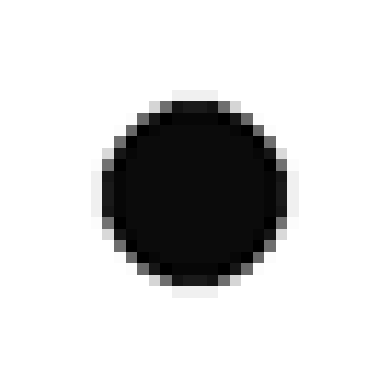

Prediction: circle
Actual: circle


In [91]:
import matplotlib.pyplot as plt

index = 10

image = X_test[index].reshape(32, 32)

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

prediction = test_predictions[index]

print("Prediction:", class_names[prediction])
print("Actual:", class_names[y_test[index]])